Non-numeric horsepower values: <StringArray>
['?']
Length: 1, dtype: str


/var/folders/kc/0kykj0rn5r9f6hn7q5g_wp9m0000gn/T/ipykernel_76103/4287111304.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['horsepower'].replace('?', np.nan, inplace=True)
/var/folders/kc/0kykj0rn5r9f6hn7q5g_wp9m0000gn/T/ipykernel_76103/4287111304.py:27: ChainedAssignmentError: A value is being set on a copy of a DataFrame o

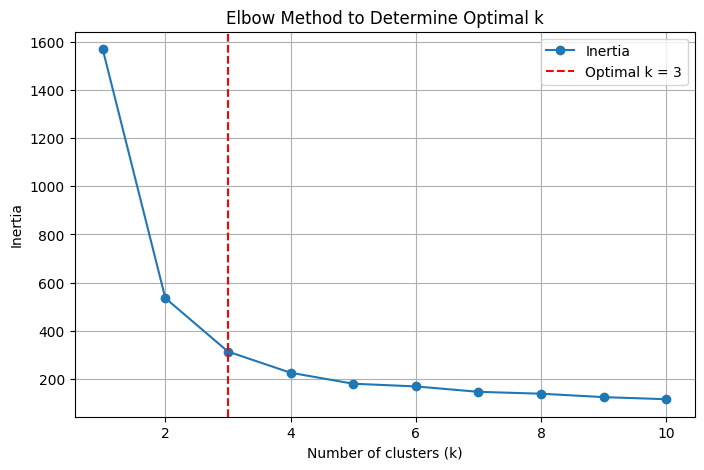

The optimal number of clusters (k) is: 3


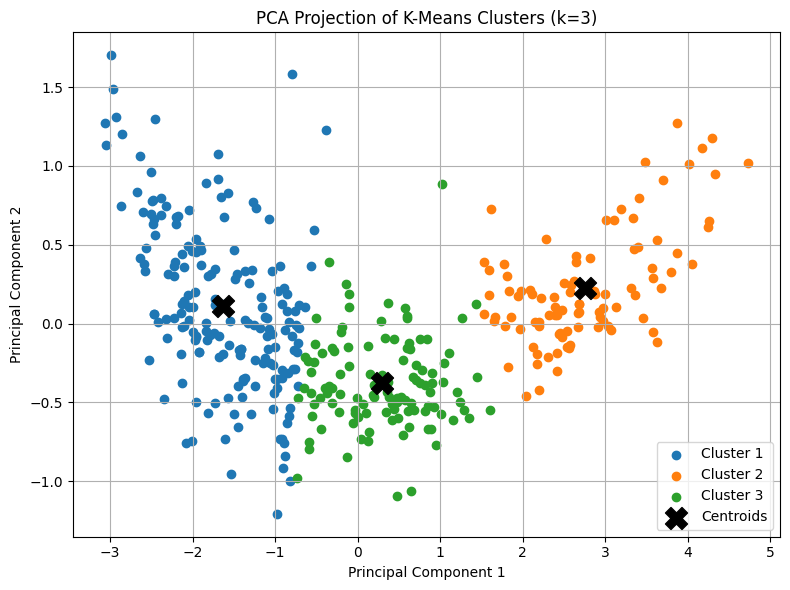

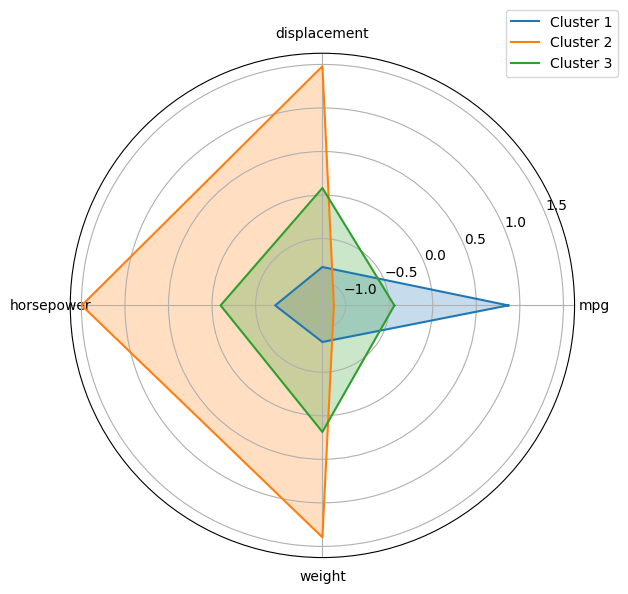

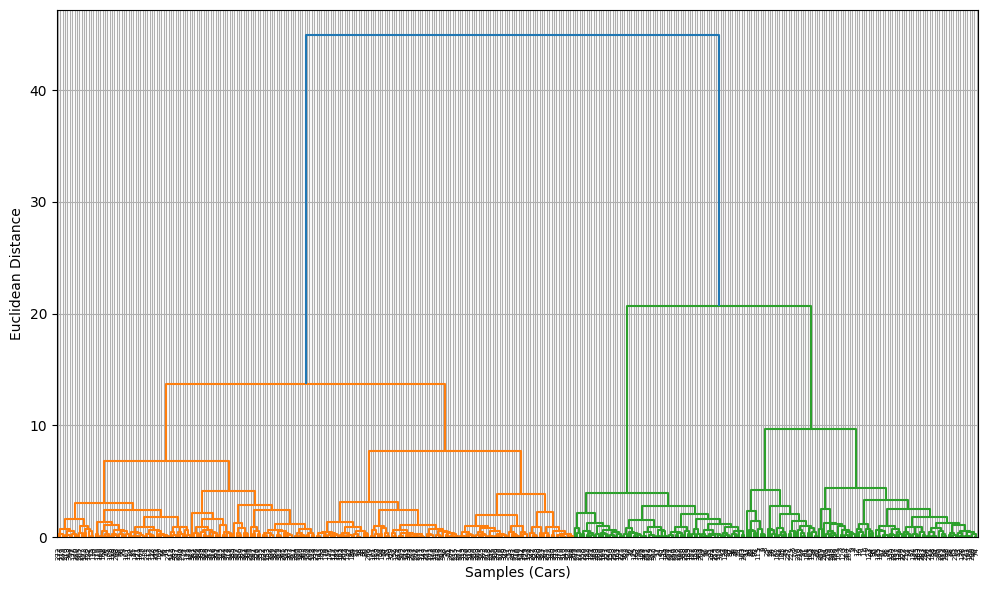

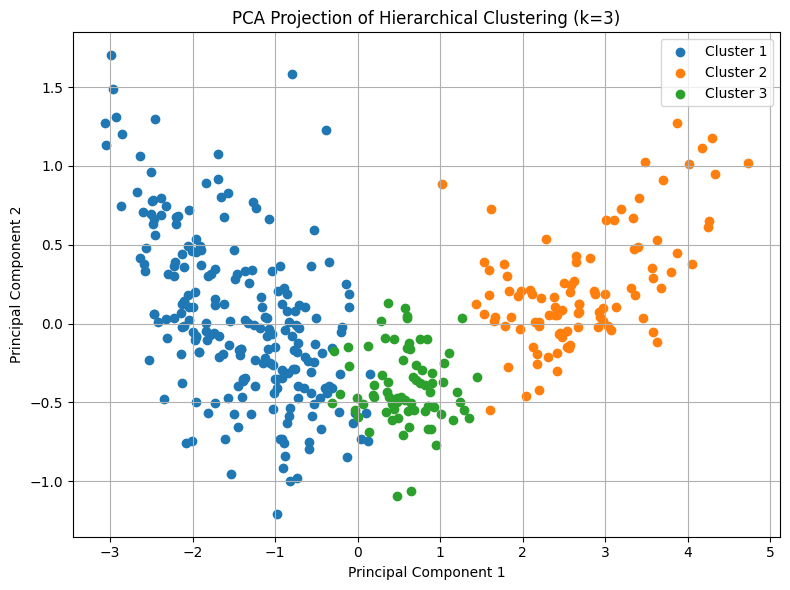

In [5]:
file_path = '../../data/s1/e4/auto-mpg.csv'

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

df = pd.read_csv(file_path)
df


# Find unique values in 'horsepower' that are not convertible to float
non_numeric_hp = df[~df['horsepower'].str.replace('.', '', 1).str.isnumeric()]['horsepower'].unique()
print("Non-numeric horsepower values:", non_numeric_hp)

import numpy as np

df['horsepower'].replace('?', np.nan, inplace=True)

df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

df.isnull().sum()  # Checking the missing values again after replacing ? with NaN

mean_hp = df['horsepower'].mean()

df['horsepower'].fillna(mean_hp, inplace=True)

df.isnull().sum()


# =============================
# K-MEANS ELBOW METHOD
# =============================

# Select relevant features based upon the research question
features = ['mpg', 'displacement', 'horsepower', 'weight']
X = df[features]

# Drop any remaining rows with NaN values in the selected features
X = X.dropna()

# Update df to match X (remove rows with NaN)
df = df.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Detect elbow
knee = KneeLocator(k_range, inertia, curve='convex', direction='decreasing')
optimal_k = knee.knee

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', label='Inertia')
plt.axvline(x=optimal_k, color='r', linestyle='--',
            label=f'Optimal k = {optimal_k}')

plt.title('Elbow Method to Determine Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True)
plt.show()

print(f"The optimal number of clusters (k) is: {optimal_k}")


# =============================
# K-MEANS WITH k=3
# =============================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = ['mpg', 'displacement', 'horsepower', 'weight']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

for cluster_id in range(k):
    plt.scatter(
        X_pca[clusters == cluster_id, 0],
        X_pca[clusters == cluster_id, 1],
        label=f'Cluster {cluster_id + 1}'
    )

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('PCA Projection of K-Means Clusters (k=3)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =============================
# RADAR PLOT OF CLUSTERS
# =============================

df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_centers_scaled = kmeans.cluster_centers_

labels = features
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))

for i in range(3):
    values = cluster_centers_scaled[i].tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Cluster {i+1}')
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.tight_layout()
plt.show()


# =============================
# HIERARCHICAL CLUSTERING
# =============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

features = ['mpg', 'displacement', 'horsepower', 'weight']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dendrogram
plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward')
)

plt.xlabel('Samples (Cars)')
plt.ylabel('Euclidean Distance')
plt.grid(True)
plt.tight_layout()
plt.show()


# Three clusters (previous elbow method)
hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)

df['cluster_hierarchical'] = hc.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

for cluster_id in range(3):
    plt.scatter(
        X_pca[df['cluster_hierarchical'] == cluster_id, 0],
        X_pca[df['cluster_hierarchical'] == cluster_id, 1],
        label=f'Cluster {cluster_id + 1}'
    )

plt.title('PCA Projection of Hierarchical Clustering (k=3)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()